<a href="https://colab.research.google.com/github/Steena123/Image-Caption-Generator/blob/main/algoimageproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Image Processing ,
Team members:
E22BCAU0148-SHREYA DAS GUPTA,
E22BCAU0133-STEENA SUSAN ABRAHAM



In [ ]:
# installing the Kaggle library
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Importing the Dog vs Cat Dataset from Kaggle

In [ ]:
# Kaggle api
!kaggle competitions download -c dogs-vs-cats

 99% 801M/812M [00:06<00:00, 175MB/s]
100% 812M/812M [00:06<00:00, 133MB/s]


In [ ]:
!ls

dogs-vs-cats.zip  kaggle.json  sample_data


In [ ]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

In [ ]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/train.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


Number of images:  25000


Printing the name of images

In [ ]:
file_names = os.listdir('/content/train/')
print(file_names)

['cat.2809.jpg', 'dog.490.jpg', 'dog.5795.jpg', 'cat.5484.jpg', 'dog.11683.jpg', 'cat.1546.jpg', 'dog.8258.jpg', 'cat.2421.jpg', 'cat.6243.jpg', 'cat.97.jpg', 'cat.5337.jpg', 'dog.9583.jpg', 'dog.6212.jpg', 'dog.11606.jpg', 'cat.12277.jpg', 'dog.7450.jpg', 'cat.244.jpg', 'dog.1955.jpg', 'dog.767.jpg', 'cat.6275.jpg', 'cat.6935.jpg', 'dog.11950.jpg', 'dog.4573.jpg', 'cat.9449.jpg', 'dog.9154.jpg', 'dog.11781.jpg', 'cat.6255.jpg', 'dog.3031.jpg', 'dog.3474.jpg', 'dog.12344.jpg', 'cat.3873.jpg', 'cat.2561.jpg', 'cat.1438.jpg', 'dog.6761.jpg', 'cat.551.jpg', 'cat.11015.jpg', 'cat.10725.jpg', 'dog.8309.jpg', 'dog.1413.jpg', 'dog.3832.jpg', 'cat.6802.jpg', 'dog.861.jpg', 'dog.4123.jpg', 'cat.8910.jpg', 'cat.11248.jpg', 'dog.4988.jpg', 'dog.7216.jpg', 'dog.944.jpg', 'dog.9889.jpg', 'dog.9845.jpg', 'cat.9617.jpg', 'cat.415.jpg', 'cat.1610.jpg', 'dog.1212.jpg', 'dog.7465.jpg', 'cat.1634.jpg', 'dog.1918.jpg', 'dog.6618.jpg', 'cat.1295.jpg', 'cat.4693.jpg', 'cat.1064.jpg', 'dog.445.jpg', 'dog.785

Importing the Dependencies

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

Displaying the images of dogs and cats

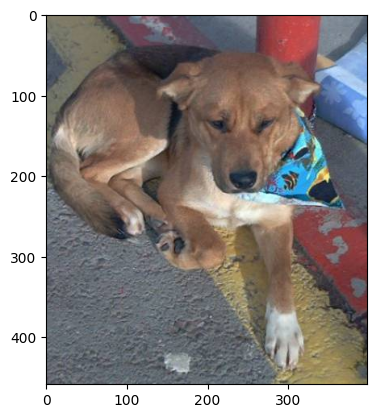

In [ ]:
# display dog image
img = mpimg.imread('/content/train/dog.490.jpg')
imgplt = plt.imshow(img)
plt.show()

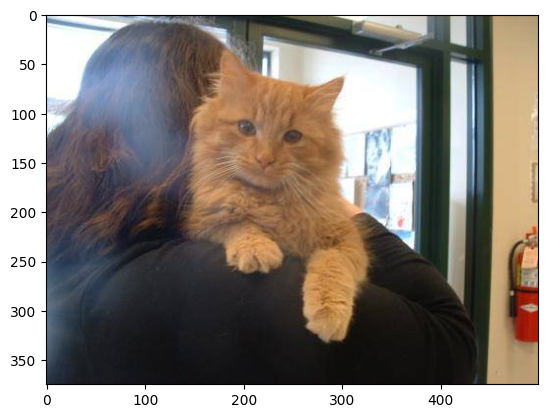

In [ ]:
# display cat image
img = mpimg.imread('/content/train/cat.5484.jpg')
imgplt = plt.imshow(img)
plt.show()

In [ ]:
file_names = os.listdir('/content/train/')

for i in range(5):

  name = file_names[i]
  print(name[0:3])

cat
dog
dog
cat
dog


In [ ]:
file_names = os.listdir('/content/train/')

dog_count = 0
cat_count = 0

for img_file in file_names:

  name = img_file[0:3]

  if name == 'dog':
    dog_count += 1

  else:
    cat_count += 1

print('Number of dog images =', dog_count)
print('Number of cat images =', cat_count)

Number of dog images = 12500
Number of cat images = 12500


Resizing all the images

In [ ]:
#creating a directory for resized images
os.mkdir('/content/image resized')

In [ ]:
original_folder = '/content/train/'
resized_folder = '/content/image resized/'

for i in range(2000):

  filename = os.listdir(original_folder)[i]
  img_path = original_folder+filename

  img = Image.open(img_path)
  img = img.resize((224, 224))
  img = img.convert('RGB')

  newImgPath = resized_folder+filename
  img.save(newImgPath)

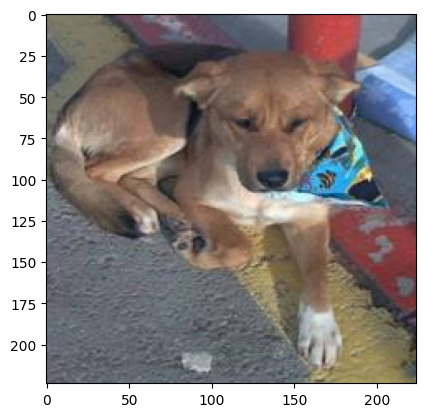

In [ ]:
# display resized dog image
img = mpimg.imread('/content/image resized/dog.490.jpg')
imgplt = plt.imshow(img)
plt.show()

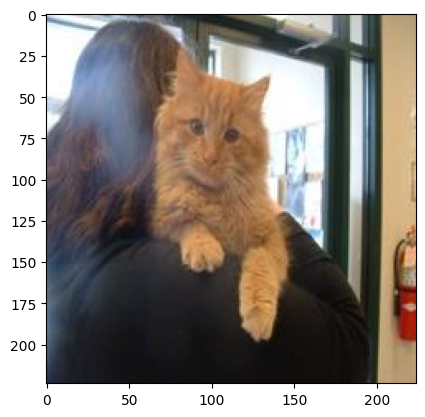

In [ ]:
# display resized cat image
img = mpimg.imread('/content/image resized/cat.5484.jpg')
imgplt = plt.imshow(img)
plt.show()

Creating labels for resized images of dogs and cats

Cat --> 0

Dog --> 1

In [ ]:
# creaing a for loop to assign labels
filenames = os.listdir('/content/image resized/')


labels = []

for i in range(2000):

  file_name = filenames[i]
  label = file_name[0:3]

  if label == 'dog':
    labels.append(1)

  else:
    labels.append(0)

In [ ]:
print(filenames[0:5])
print(len(filenames))

['cat.2809.jpg', 'dog.490.jpg', 'dog.5795.jpg', 'cat.5484.jpg', 'dog.11683.jpg']
2000


In [ ]:
print(labels[0:5])
print(len(labels))

[0, 1, 1, 0, 1]
2000


In [ ]:
# counting the images of dogs and cats out of 2000 images
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[1001  999]


Converting all the resized images to numpy arrays

In [ ]:
import cv2
import glob

In [ ]:
image_directory = '/content/image resized/'
image_extension = ['png', 'jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [ ]:
print(dog_cat_images)

[[[[ 77  86  95]
   [ 77  86  95]
   [ 77  86  95]
   ...
   [ 48  39  49]
   [ 53  44  54]
   [ 58  50  57]]

  [[ 78  87  96]
   [ 78  87  96]
   [ 79  88  97]
   ...
   [ 54  45  55]
   [ 66  58  65]
   [ 77  70  75]]

  [[ 80  89  98]
   [ 80  89  98]
   [ 80  89  98]
   ...
   [125 119 124]
   [187 181 186]
   [231 226 228]]

  ...

  [[212 217 255]
   [211 216 255]
   [209 214 253]
   ...
   [233 243 253]
   [234 243 255]
   [234 244 254]]

  [[205 207 255]
   [204 208 255]
   [203 207 255]
   ...
   [233 246 254]
   [235 247 255]
   [235 248 255]]

  [[199 200 255]
   [200 201 255]
   [200 204 255]
   ...
   [235 248 255]
   [237 250 255]
   [238 251 255]]]


 [[[104 126 131]
   [ 98 120 125]
   [ 96 118 123]
   ...
   [115 105  95]
   [106  97  87]
   [111 102  92]]

  [[107 129 134]
   [101 123 128]
   [ 99 121 126]
   ...
   [115 105  95]
   [108  99  89]
   [109 100  90]]

  [[106 126 131]
   [102 122 127]
   [102 122 127]
   ...
   [114 104  94]
   [110 100  90]
   [107  97

In [ ]:
type(dog_cat_images)

numpy.ndarray

In [ ]:
print(dog_cat_images.shape)

(2000, 224, 224, 3)


In [ ]:
X = dog_cat_images
Y = np.asarray(labels)

Train Test Split

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


1600 --> training images

400 --> test images

In [ ]:
# scaling the data
X_train_scaled = X_train/255

X_test_scaled = X_test/255

In [ ]:
print(X_train_scaled)

[[[[0.10196078 0.10588235 0.6627451 ]
   [0.09411765 0.09803922 0.65490196]
   [0.09803922 0.08627451 0.65490196]
   ...
   [0.70980392 0.69803922 0.63921569]
   [0.89019608 0.8745098  0.80392157]
   [0.78823529 0.77254902 0.70196078]]

  [[0.10196078 0.10980392 0.65098039]
   [0.09803922 0.10588235 0.64705882]
   [0.09019608 0.09411765 0.64313725]
   ...
   [0.63529412 0.62352941 0.56470588]
   [0.81568627 0.79607843 0.7372549 ]
   [0.80784314 0.79215686 0.72156863]]

  [[0.10196078 0.12156863 0.63921569]
   [0.09411765 0.11372549 0.63137255]
   [0.08627451 0.10588235 0.62745098]
   ...
   [0.47843137 0.46666667 0.41176471]
   [0.55686275 0.54509804 0.49019608]
   [0.58431373 0.57254902 0.51372549]]

  ...

  [[0.23137255 0.30196078 0.32941176]
   [0.27058824 0.34509804 0.37647059]
   [0.31764706 0.38823529 0.43137255]
   ...
   [0.54509804 0.48627451 0.47843137]
   [0.54117647 0.48235294 0.4745098 ]
   [0.51372549 0.45490196 0.44705882]]

  [[0.23529412 0.30980392 0.34117647]
   [0.2

Building the Neural Network

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub

In [ ]:
mobilenet_model = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'

pretrained_model = hub.KerasLayer(mobilenet_model, input_shape=(224,224,3), trainable=False)

In [ ]:
num_of_classes = 2

model = tf.keras.Sequential([

    pretrained_model,
    tf.keras.layers.Dense(num_of_classes)

])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 2)                 2562      
                                                                 
Total params: 2260546 (8.62 MB)
Trainable params: 2562 (10.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [ ]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['acc']
)

In [ ]:
model.fit(X_train_scaled, Y_train, epochs=5)

Epoch 1/5
50/50 [==============================] - 67s 1s/step - loss: 0.1908 - acc: 0.9194
Epoch 2/5
50/50 [==============================] - 60s 1s/step - loss: 0.0647 - acc: 0.9781
Epoch 3/5
50/50 [==============================] - 60s 1s/step - loss: 0.0484 - acc: 0.9831
Epoch 4/5
50/50 [==============================] - 60s 1s/step - loss: 0.0359 - acc: 0.9894
Epoch 5/5
50/50 [==============================] - 59s 1s/step - loss: 0.0279 - acc: 0.9950


In [ ]:
score, acc = model.evaluate(X_test_scaled, Y_test)
print('Test Loss =', score)
print('Test Accuracy =', acc)

13/13 [==============================] - 17s 1s/step - loss: 0.0649 - acc: 0.9725
Test Loss = 0.06490762531757355
Test Accuracy = 0.9725000262260437


Path of the image to be predicted: /content/dog.jpg


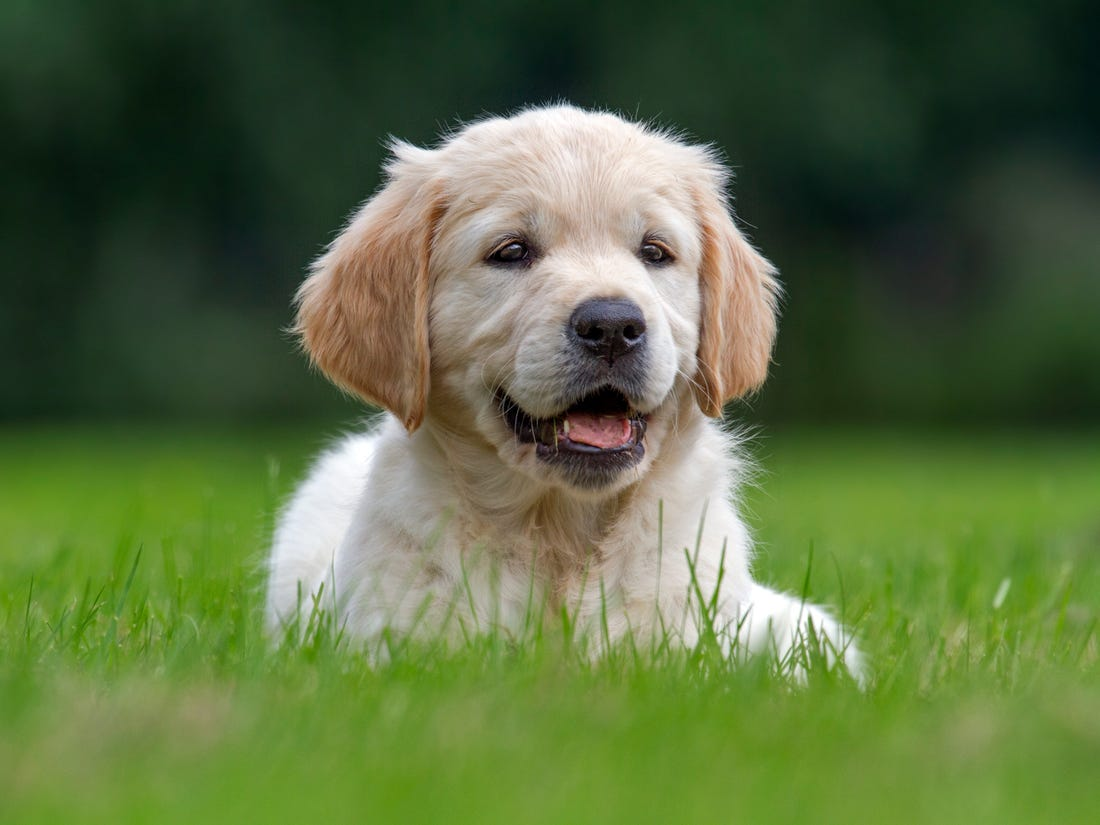

1/1 [==============================] - 1s 672ms/step
[[-4.7019296  3.7057757]]
1
The image represents a Dog


In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')